# Feature Engineering

**Goal**: Build a single, clean feature matrix that combines everything we've learned into one dataset ready for the CoT agent.

This notebook merges:
1. **Event counts** (from the occurrence matrix)
2. **Sequence features** (length, n-gram matches, skeleton)
3. **Temporal features** (latency, inter-event intervals)
4. **Failure mode labels** (from NB05 taxonomy)

The output is a single CSV file that the CoT agent will use as its input in Phase 3.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json
import os

sns.set_style("whitegrid")

DATA_DIR = "../../preprocessed"

# Load base data
matrix_df = pd.read_csv(os.path.join(DATA_DIR, "Event_occurrence_matrix.csv"))
traces_df = pd.read_csv(os.path.join(DATA_DIR, "Event_traces.csv"))
templates_df = pd.read_csv(os.path.join(DATA_DIR, "HDFS.log_templates.csv"))

# Load our taxonomy
with open('../data/root_cause_taxonomy.json', 'r') as f:
    taxonomy = json.load(f)

# Load sequence findings
with open('../data/sequence_analysis_findings.json', 'r') as f:
    seq_findings = json.load(f)

print(f"✅ All data loaded")
print(f"   Matrix: {matrix_df.shape}")
print(f"   Traces: {traces_df.shape}")
print(f"   Taxonomy: {len(taxonomy['failure_modes'])} failure modes")


✅ All data loaded
   Matrix: (575061, 32)
   Traces: (575061, 6)
   Taxonomy: 8 failure modes


## : Extract Sequence & Temporal Features

From `Event_traces.csv`, we extract:
- **Sequence length**: number of events in the trace
- **Unique events**: how many distinct event types appear
- **Error event count**: how many known error events (E4, E7, E10, etc.)
- **Has completion**: whether the trace ends with completion events (E2, E9)
- **Latency**: total trace duration
- **Mean/Max interval**: timing between events


In [26]:
traces_df.head()

,BlockId,Label,Type,Features,TimeInterval,Latency
0,blk_-1608999687919862906,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
1,blk_7503483334202473044,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
2,blk_-3544583377289625738,Fail,21.0,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",3797
3,blk_-9073992586687739851,Success,NaN,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",50448
4,blk_7854771516489510256,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50583


In [27]:
traces_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 575061 entries, 0 to 575060
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   BlockId       575061 non-null  str    
 1   Label         575061 non-null  str    
 2   Type          16838 non-null   float64
 3   Features      575061 non-null  str    
 4   TimeInterval  575061 non-null  str    
 5   Latency       575061 non-null  int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 26.3 MB


In [ ]:
# Parse sequences
def parse_features(x):
    if pd.isna(x):
        return []
    return [event.strip() for event in x.strip("[]").split(",") if event.strip()]

traces_df["sequence"] = traces_df["Features"].apply(parse_features)

# Parse time intervals
traces_df['intervals'] = traces_df['TimeInterval'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else [])






# ---- Sequence features ----
traces_df['seq_length'] = traces_df['sequence'].apply(len)
traces_df['unique_events'] = traces_df['sequence'].apply(lambda s: len(set(s)))








# Error events (from our EDA)
error_events = {'E4', 'E7', 'E10', 'E12', 'E13', 'E14', 'E17', 'E20', 'E27', 'E28', 'E29'}
traces_df['error_count'] = traces_df['sequence'].apply(
    lambda s: sum(1 for e in s if e in error_events))





# Completion events
completion_events = {'E2', 'E9'}
traces_df['has_completion'] = traces_df['sequence'].apply(
    lambda s: 1 if any(e in completion_events for e in s) else 0)






# ---- Temporal features ----
traces_df['mean_interval'] = traces_df['intervals'].apply(
    lambda x: np.mean(x) if len(x) > 0 else 0)
traces_df['max_interval'] = traces_df['intervals'].apply(
    lambda x: np.max(x) if len(x) > 0 else 0)
traces_df['std_interval'] = traces_df['intervals'].apply(
    lambda x: np.std(x) if len(x) > 0 else 0)



# ---- Anomaly-exclusive 4-gram matching ----
# Load the anomaly-exclusive 4-grams from our findings
excl_4grams = set()
for item in seq_findings.get('anomaly_exclusive_4grams', []):
    pattern = tuple(item['pattern'])
    excl_4grams.add(pattern)

def count_anomaly_4grams(sequence):
    """Count how many anomaly-exclusive 4-grams appear in a sequence."""
    count = 0
    for i in range(len(sequence) - 3):
        gram = tuple(sequence[i:i+4])
        if gram in excl_4grams:
            count += 1
    return count

traces_df['anomaly_4gram_count'] = traces_df['sequence'].apply(count_anomaly_4grams)

print(f" Extracted sequence and temporal features")
print(f"   Columns: {list(traces_df.columns)}")


✅ Extracted sequence and temporal features
   Columns: ['BlockId', 'Label', 'Type', 'Features', 'TimeInterval', 'Latency', 'sequence', 'intervals', 'seq_length', 'unique_events', 'error_count', 'has_completion', 'mean_interval', 'max_interval', 'std_interval', 'anomaly_4gram_count']


##  Add Failure Mode Labels

Using the type-to-mode mapping from our taxonomy (NB05), we label each anomaly trace with its failure mode. Normal traces get the label "NORMAL".


In [29]:
# Build the type-to-mode mapping from our taxonomy
type_to_mode = taxonomy['type_to_mode_mapping']

def get_failure_mode(row):
    if row['Label'] == 'Success':
        return 'NORMAL'
    atype = str(int(row['Type'])) if pd.notna(row['Type']) else None
    if atype and atype in type_to_mode:
        return type_to_mode[atype]['failure_mode']
    return 'UNKNOWN_FAILURE'

traces_df['failure_mode'] = traces_df.apply(get_failure_mode, axis=1)

# Show distribution
print(f"Failure mode distribution:")
mode_dist = traces_df['failure_mode'].value_counts()
for mode, count in mode_dist.items():
    pct = count / len(traces_df) * 100
    print(f"   {mode:<30} {count:>8,} ({pct:.2f}%)")


Failure mode distribution:
   NORMAL                          558,223 (97.07%)
   SERVE_FAILURE                     4,811 (0.84%)
   BLOCK_LIFECYCLE_ERROR             4,374 (0.76%)
   WRITE_PATH_FAILURE                3,226 (0.56%)
   INCOMPLETE_PIPELINE               2,950 (0.51%)
   METADATA_INCONSISTENCY              953 (0.17%)
   EMPTY_PACKET_LOOP                   476 (0.08%)
   REPLICATION_FAILURE                  45 (0.01%)
   SILENT_RECOVERY                       3 (0.00%)


##  Build the Final Feature Matrix

We merge the event count matrix with our engineered features into one clean dataset. Each row is one block trace, each column is a feature.


In [30]:
# Select the features we want from traces_df
trace_features = traces_df[[
    'BlockId', 'Label', 'failure_mode',
    'seq_length', 'unique_events', 'error_count', 'has_completion',
    'Latency', 'mean_interval', 'max_interval', 'std_interval',
    'anomaly_4gram_count'
]].copy()

# Merge with event count matrix
feature_matrix = matrix_df.merge(trace_features, on='BlockId', how='inner', suffixes=('_matrix', '_trace'))

# Clean up: use the Label from matrix (should be identical)
if 'Label_matrix' in feature_matrix.columns:
    feature_matrix['Label'] = feature_matrix['Label_matrix']
    feature_matrix.drop(columns=['Label_matrix', 'Label_trace'], inplace=True, errors='ignore')

# Add binary label
feature_matrix['is_anomaly'] = (feature_matrix['Label'] == 'Fail').astype(int)

print(f"✅ Feature matrix built!")
print(f"   Shape: {feature_matrix.shape}")
print(f"   Columns ({len(feature_matrix.columns)}):")
for col in feature_matrix.columns:
    print(f"      {col}")


✅ Feature matrix built!
   Shape: (575061, 43)
   Columns (43):
      BlockId
      Type
      E1
      E2
      E3
      E4
      E5
      E6
      E7
      E8
      E9
      E10
      E11
      E12
      E13
      E14
      E15
      E16
      E17
      E18
      E19
      E20
      E21
      E22
      E23
      E24
      E25
      E26
      E27
      E28
      E29
      failure_mode
      seq_length
      unique_events
      error_count
      has_completion
      Latency
      mean_interval
      max_interval
      std_interval
      anomaly_4gram_count
      Label
      is_anomaly


Top 15 features correlated with anomaly (by absolute correlation):
Feature                    Correlation
────────────────────────────────────────
   E9                         -0.6026 -
   has_completion             -0.6014 -
   E11                        -0.5978 -
   E20                         0.5256 +
   anomaly_4gram_count         0.4245 +
   E7                          0.4241 +
   E18                         0.3123 +
   E25                         0.3123 +
   E16                         0.3100 +
   E6                          0.2999 +
   E28                         0.2614 +
   E26                        -0.2549 -
   E27                         0.2363 +
   E5                         -0.2107 -
   E13                         0.1678 +


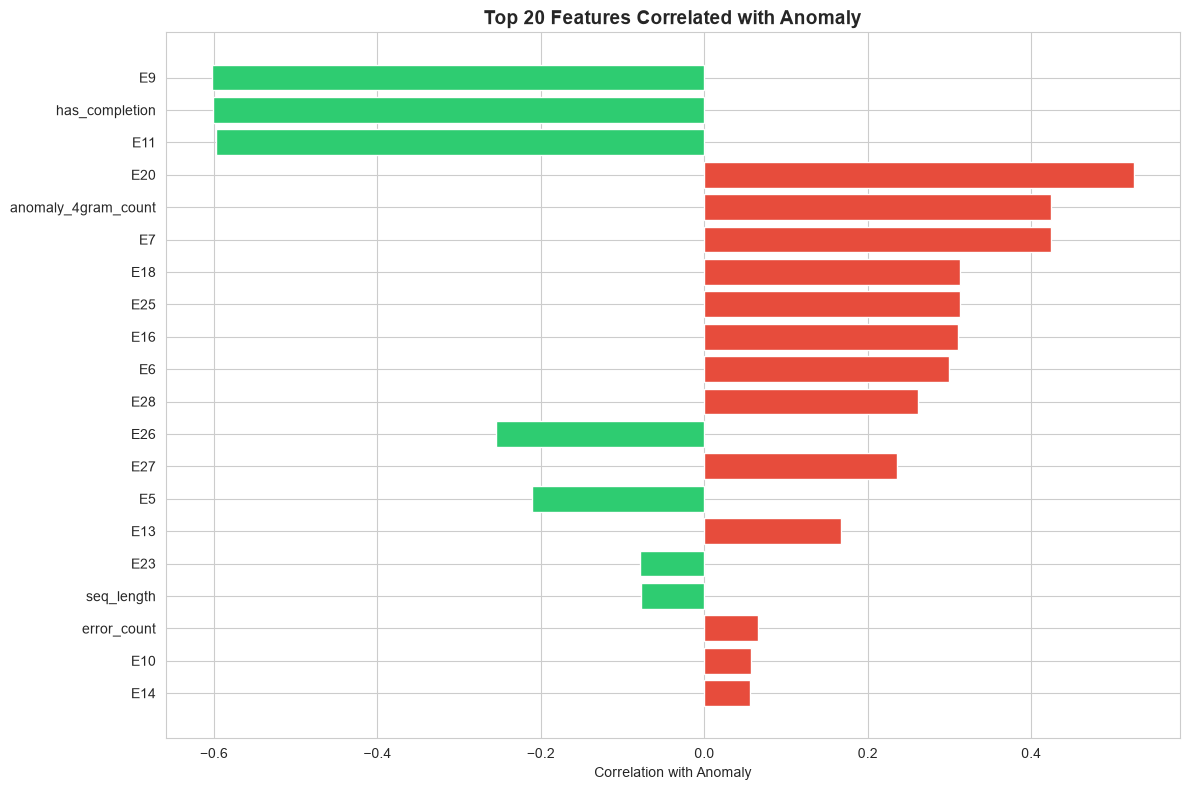

In [31]:
# Numeric feature columns for correlation
numeric_features = [
    'seq_length', 'unique_events', 'error_count', 'has_completion',
    'Latency', 'mean_interval', 'max_interval', 'std_interval',
    'anomaly_4gram_count', 'is_anomaly'
]

# Add event count columns
event_cols = [c for c in feature_matrix.columns if c.startswith('E') and c[1:].isdigit()]
all_features = numeric_features + event_cols

# Correlation with is_anomaly
corr_with_anomaly = feature_matrix[all_features].corr()['is_anomaly'].drop('is_anomaly')
corr_with_anomaly = corr_with_anomaly.sort_values(key=abs, ascending=False)

print("Top 15 features correlated with anomaly (by absolute correlation):")
print(f"{'Feature':<25} {'Correlation':>12}")
print(f"{'─'*40}")
for feat, corr in corr_with_anomaly.head(15).items():
    direction = "+" if corr > 0 else "-"
    print(f"   {feat:<22} {corr:>11.4f} {direction}")

# Visualize top correlations
fig, ax = plt.subplots(figsize=(12, 8))
top_features = corr_with_anomaly.head(20)
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_features.values]
ax.barh(range(len(top_features)), top_features.values, color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index)
ax.set_xlabel('Correlation with Anomaly')
ax.set_title('Top 20 Features Correlated with Anomaly', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


##  Prepare Sample Traces for the CoT Agent

The CoT agent needs actual trace examples to reason about. We select representative samples from each failure mode — these become the test cases and few-shot examples for Phase 3.


In [32]:
# Select representative samples from each failure mode
samples = {}
for mode in traces_df['failure_mode'].unique():
    mode_traces = traces_df[traces_df['failure_mode'] == mode]
    n_samples = min(5, len(mode_traces))
    sampled = mode_traces.sample(n_samples, random_state=42)
    
    samples[mode] = []
    for _, row in sampled.iterrows():
        sample = {
            "block_id": row['BlockId'],
            "sequence": row['sequence'][:30],  # Truncate for readability
            "full_length": len(row['sequence']),
            "error_count": int(row['error_count']),
            "has_completion": int(row['has_completion']),
            "latency": float(row['Latency']),
            "anomaly_4gram_count": int(row['anomaly_4gram_count']),
            "failure_mode": mode
        }
        samples[mode].append(sample)

# Print summary
for mode, mode_samples in samples.items():
    print(f"\n{'═'*60}")
    print(f"  {mode} ({len(mode_samples)} samples)")
    print(f"{'═'*60}")
    for s in mode_samples[:2]:  # Show 2 per mode
        seq_str = ' → '.join(s['sequence'][:10])
        print(f"  Block: {s['block_id'][:30]}...")
        print(f"  Seq:   {seq_str}{'...' if len(s['sequence']) > 10 else ''}")
        print(f"  Errors: {s['error_count']}, Completion: {s['has_completion']}, "
              f"Latency: {s['latency']:.0f}s, 4-grams: {s['anomaly_4gram_count']}")
        print()



════════════════════════════════════════════════════════════
  NORMAL (5 samples)
════════════════════════════════════════════════════════════
  Block: blk_3173365234163800688...
  Seq:   E5 → E22 → E5 → E5 → E11 → E9 → E11 → E9 → E11 → E9...
  Errors: 0, Completion: 1, Latency: 11395s, 4-grams: 0

  Block: blk_3310549543855686238...
  Seq:   E5 → E5 → E22 → E5 → E11 → E9 → E11 → E9 → E11 → E9...
  Errors: 0, Completion: 1, Latency: 30s, 4-grams: 0


════════════════════════════════════════════════════════════
  SERVE_FAILURE (5 samples)
════════════════════════════════════════════════════════════
  Block: blk_-7484022525840975897...
  Seq:   E22 → E5 → E5 → E5 → E26 → E26 → E26 → E11 → E9 → E11...
  Errors: 5, Completion: 1, Latency: 34290s, 4-grams: 0

  Block: blk_-1330299732182917002...
  Seq:   E5 → E5 → E22 → E5 → E11 → E9 → E11 → E9 → E26 → E26...
  Errors: 2, Completion: 1, Latency: 51732s, 4-grams: 5


════════════════════════════════════════════════════════════
  BLOCK_LIFEC

## Save Results :

In [ ]:
# 1. Save the feature matrix
os.makedirs('../data', exist_ok=True)

feature_matrix.to_csv('../data/feature_matrix.csv', index=False)
print(f"✅ Saved feature matrix: {feature_matrix.shape}")

# 2. Save the sample traces for CoT agent
with open('../data/cot_sample_traces.json', 'w') as f:
    json.dump(samples, f, indent=2)
print(f"✅ Saved {sum(len(v) for v in samples.values())} sample traces for CoT agent")

# 3. Save a summary report
summary = {
    "dataset_stats": {
        "total_traces": len(feature_matrix),
        "anomaly_traces": int(feature_matrix['is_anomaly'].sum()),
        "normal_traces": int((1 - feature_matrix['is_anomaly']).sum()),
        "num_features": len(feature_matrix.columns),
        "num_failure_modes": len([m for m in traces_df['failure_mode'].unique() if m != 'NORMAL']),
    },
    "top_features": {
        feat: float(corr) for feat, corr in corr_with_anomaly.head(10).items()
    },
    "failure_mode_distribution": {
        mode: int(count) for mode, count in mode_dist.items()
    }
}

with open('../data/feature_engineering_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f" Saved summary report")

print(f"\n{'═'*60}")
print(f"  LOCAL EDA PHASE COMPLETE!")
print(f"{'═'*60}")
print(f"  Files ready for Phase 3 (Colab/Kaggle):")
print(f"     data/feature_matrix.csv")
print(f"     data/root_cause_taxonomy.json")
print(f"     data/sequence_analysis_findings.json")
print(f"     data/cot_sample_traces.json")
print(f"     data/feature_engineering_summary.json")


✅ Saved feature matrix: (575061, 43)
✅ Saved 43 sample traces for CoT agent
✅ Saved summary report

════════════════════════════════════════════════════════════
  LOCAL EDA PHASE COMPLETE!
════════════════════════════════════════════════════════════
  Files ready for Phase 3 (Colab/Kaggle):
    📁 data/feature_matrix.csv
    📁 data/root_cause_taxonomy.json
    📁 data/sequence_analysis_findings.json
    📁 data/cot_sample_traces.json
    📁 data/feature_engineering_summary.json


In [34]:
with open('../data/root_cause_taxonomy.json', 'r') as f:
    taxonomy = json.load(f)

In [35]:
# show just the names of the failure modes for brevity 
for mode in taxonomy['failure_modes']:
   print(mode)

WRITE_PATH_FAILURE
EMPTY_PACKET_LOOP
SERVE_FAILURE
METADATA_INCONSISTENCY
REPLICATION_FAILURE
BLOCK_LIFECYCLE_ERROR
INCOMPLETE_PIPELINE
SILENT_RECOVERY
